In [1]:
from helper_functions import sensitivity_quad_unif
from helper_functions import construct_E_C
from helper_functions import sens_recovery
from sklearn.cluster import SpectralCoclustering
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
list_of_sens_score = []
beta_vals = [[1,0,1,0,1,0,0.3,0,0.3,0,0.3,0],
             [0.5,0.25,0,0,0,0,1,0.5,1,0.5,0.75,0],
             [1,1,0.75,0.5,1,0,0.75,0,0.75,0,0.75,0],
             [0,0,0.5,0.0,0.25,0,0.75,0,0.5,0.125,0.5,0.25]]
for i in range(4):
    list_of_sens_score.append(sensitivity_quad_unif(beta_vals[i]))

In [3]:
print(list_of_sens_score)

[[0.3058103975535168, 0.3058103975535168, 0.3058103975535168, 0.027522935779816512, 0.027522935779816512, 0.027522935779816512], [0.10007358351729212, 0.0, 0.0, 0.4002943340691685, 0.4002943340691685, 0.09933774834437097], [0.488, 0.1895000000000001, 0.11999999999999994, 0.06749999999999998, 0.06749999999999998, 0.06749999999999998], [0.0, 0.13636363636363633, 0.03409090909090908, 0.3068181818181817, 0.21363636363636426, 0.30909090909090864]]


In [4]:
#np_list_of_sens_score = np.array(list_of_sens_score)
clustering = SpectralCoclustering(n_clusters=2, random_state=0).fit(list_of_sens_score)
clustering.biclusters_
#print(len(clustering.biclusters_[1]))

C:\Users\wsfishe\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


(array([[ True, False,  True, False],
        [False,  True, False,  True]]),
 array([[ True,  True,  True, False, False, False],
        [False, False, False,  True,  True,  True]]))

(0.6266606507244197, 0.6266606507244197, 0.6266606507244197, 0.05639945856519777, 0.05639945856519777, 0.05639945856519777, 0.20506881868297566, 0.8202752747319026, 0.8202752747319026, 0.20356095972207167, 1.0, 0.38831967213114776, 0.24590163934426218, 0.1383196721311475, 0.1383196721311475, 0.1383196721311475, 0.27943368107302524, 0.06985842026825631, 0.6287257824143068, 0.4377794336810743, 0.6333830104321898)


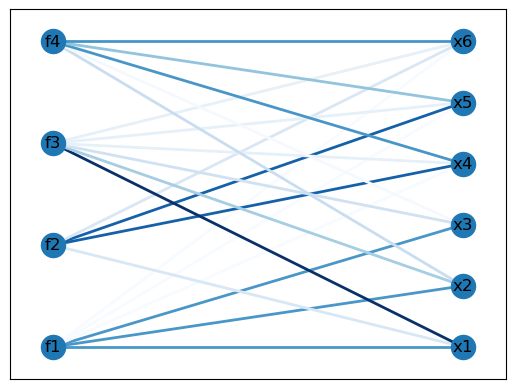

In [5]:
B = nx.Graph()

f_nodes = ['f1', 'f2', 'f3','f4']
x_nodes = ['x1', 'x2','x3','x4','x5','x6']
# Add nodes with the bipartite attribute
B.add_nodes_from(f_nodes, bipartite=0)  # Set 1
B.add_nodes_from(x_nodes, bipartite=1)        # Set 2

# Add weighted edges between nodes of opposite sets
#B.add_edges_from([('A1', 'B1', {'weight': 5}),
                  #('A2', 'B1', {'weight': 3}),
                  #('A3', 'B2', {'weight': 4})])
edge_set = []
for i in range(4):
    for j in range(6):
        if list_of_sens_score[i][j] > 0.0:
            edge_set.append((f_nodes[i],x_nodes[j],{'weight': list_of_sens_score[i][j]/0.488}))

B.add_edges_from(edge_set)

# Position nodes using bipartite layout
#pos = nx.bipartite_layout(B, nodes=f_nodes)

# Draw the graph
#nx.draw(B, pos, with_labels=True, node_color=['lightblue', 'lightgreen'])
#labels = nx.get_edge_attributes(B, 'weight')
#nx.draw_networkx_edge_labels(B, pos, edge_labels=labels)

# Show the plot
#plt.show()

edges,weights = zip(*nx.get_edge_attributes(B,'weight').items())

print(weights)

nx.draw_networkx(B,pos = nx.drawing.layout.bipartite_layout(B, f_nodes),edge_color= weights, width = 2,edge_cmap=plt.cm.Blues)


(0.6266606507244197, 0.6266606507244197, 0.6266606507244197, 1.0, 0.38831967213114776, 0.24590163934426218, 0.8202752747319026, 0.8202752747319026, 0.20356095972207167, 0.6287257824143068, 0.4377794336810743, 0.6333830104321898)


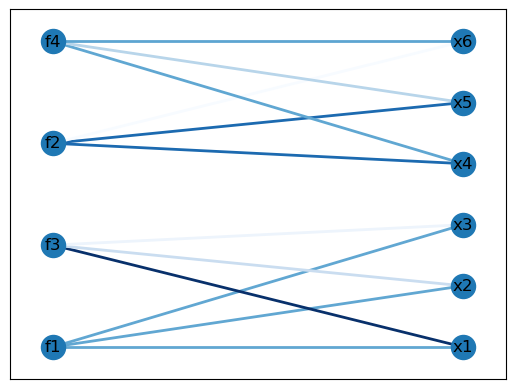

In [6]:
B_new = nx.Graph()

f_nodes_new = ['f1', 'f3', 'f2','f4']
x_nodes_new = ['x1', 'x2','x3','x4','x5','x6']
# Add nodes with the bipartite attribute
B_new.add_nodes_from(f_nodes_new, bipartite=0)  # Set 1
B_new.add_nodes_from(x_nodes_new, bipartite=1)        # Set 2

# Add weighted edges between nodes of opposite sets
#B.add_edges_from([('A1', 'B1', {'weight': 5}),
                  #('A2', 'B1', {'weight': 3}),
                  #('A3', 'B2', {'weight': 4})])
edge_set_new = [(f_nodes_new[0],x_nodes_new[0],{'weight': list_of_sens_score[0][0]/0.488}),(f_nodes_new[0],x_nodes_new[1],{'weight': list_of_sens_score[0][1]/0.488}),
               (f_nodes_new[0],x_nodes_new[2],{'weight': list_of_sens_score[0][2]/0.488}),(f_nodes_new[1],x_nodes_new[0],{'weight': list_of_sens_score[2][0]/0.488}),
               (f_nodes_new[1],x_nodes_new[1],{'weight': list_of_sens_score[2][1]/0.488}),(f_nodes_new[1],x_nodes_new[2],{'weight': list_of_sens_score[2][2]/0.488}),
               (f_nodes_new[2],x_nodes_new[3],{'weight': list_of_sens_score[1][3]/0.488}),(f_nodes_new[2],x_nodes_new[4],{'weight': list_of_sens_score[1][4]/0.488}),
               (f_nodes_new[2],x_nodes_new[5],{'weight': list_of_sens_score[1][5]/0.488}),(f_nodes_new[3],x_nodes_new[3],{'weight': list_of_sens_score[3][3]/0.488}),
               (f_nodes_new[3],x_nodes_new[4],{'weight': list_of_sens_score[3][4]/0.488}),(f_nodes_new[3],x_nodes_new[5],{'weight': list_of_sens_score[3][5]/0.488})]


B_new.add_edges_from(edge_set_new)

# Position nodes using bipartite layout
#pos = nx.bipartite_layout(B, nodes=f_nodes)

# Draw the graph
#nx.draw(B, pos, with_labels=True, node_color=['lightblue', 'lightgreen'])
#labels = nx.get_edge_attributes(B, 'weight')
#nx.draw_networkx_edge_labels(B, pos, edge_labels=labels)

# Show the plot
#plt.show()

edges_new,weights_new = zip(*nx.get_edge_attributes(B_new,'weight').items())

print(weights_new)

nx.draw_networkx(B_new,pos = nx.drawing.layout.bipartite_layout(B_new, f_nodes_new),edge_color= weights_new, width = 2,edge_cmap=plt.cm.Blues)


In [10]:
#Test sensitivity recovery.
E_C_test = construct_E_C(clustering.biclusters_[0],clustering.biclusters_[1])

deltas_test = [0.95,0.9,0.85,0.9]

print(sens_recovery(list_of_sens_score,deltas_test,clustering.biclusters_[0],clustering.biclusters_[1],E_C_test,100))


Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: 11th Gen Intel(R) Core(TM) i9-11900H @ 2.50GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 28 rows, 25 columns and 57 nonzeros
Model fingerprint: 0x78710c37
Variable types: 0 continuous, 25 integer (25 binary)
Coefficient statistics:
  Matrix range     [3e-02, 1e+00]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e-01, 1e+00]
Found heuristic solution: objective 1320.6613845
Presolve removed 28 rows and 25 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.00 seconds (0.00 work units)
Thread count was 1 (of 16 available processors)

Solution count 1: 1320.66 

Optimal solution found (tolerance 1.00e-04)
Best objective 1